In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
print(data.target_names)
print(data.feature_names)

['malignant' 'benign']
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [ ]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")
full_data = pd.concat([X, y], axis=1)

In [ ]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
full_data.isna().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [ ]:
full_data.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Baseline and his metrics

In [ ]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)
pred_baseline

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1])

In [ ]:
from sklearn.metrics import classification_report

baseline_metrics = classification_report(y_test, pred_baseline)
print(baseline_metrics)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.62      1.00      0.77        71

    accuracy                           0.62       114
   macro avg       0.31      0.50      0.38       114
weighted avg       0.39      0.62      0.48       114



/home/den/miniconda3/envs/universal/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/den/miniconda3/envs/universal/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/den/miniconda3/envs/universal/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [ ]:
from sklearn.metrics import confusion_matrix

baseline_conf_mtx = confusion_matrix(y_test, pred_baseline)
print(baseline_conf_mtx)

[[ 0 43]
 [ 0 71]]


In [ ]:
from sklearn.metrics import roc_auc_score

proba_baseline = baseline.predict_proba(X_test)
roc_auc_score_baseline = roc_auc_score(y_test, proba_baseline[:, 1])
print(roc_auc_score_baseline)

0.5


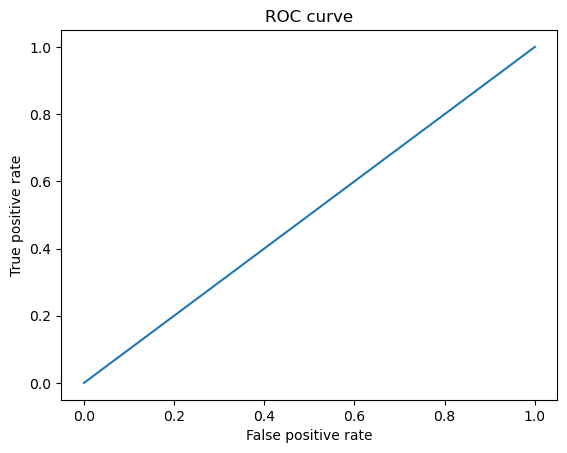

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, proba_baseline[:, 1])

plt.plot(fpr, tpr)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.show()

Fitting logistic regression

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model_log_reg = LogisticRegression()
model_log_reg.fit(X_train_scaled, y_train)
pred_log_reg = model_log_reg.predict(X_test_scaled)
print(pred_log_reg)

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]


Logistic Regression Metrics and comparison of the model with the baseline

In [ ]:
classification_report_log_reg = classification_report(y_test, pred_log_reg)
print(classification_report_log_reg)
print(baseline_metrics)

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.62      1.00      0.77        71

    accuracy                           0.62       114
   macro avg       0.31      0.50      0.38       114
weighted avg       0.39      0.62      0.48       114



In [ ]:
conf_mtx_log_reg = confusion_matrix(y_test, pred_log_reg)
print(conf_mtx_log_reg)
print(baseline_conf_mtx)

[[41  2]
 [ 1 70]]
[[ 0 43]
 [ 0 71]]


In [ ]:
proba_log_reg = model_log_reg.predict_proba(X_test_scaled)
roc_auc_score_log_reg = roc_auc_score(y_test, proba_log_reg[:, 1])
print(roc_auc_score_log_reg)
print(roc_auc_score_baseline)

0.99737962659679
0.5


In [ ]:
fpr_log_reg, tpr_log_reg, threshold_log_reg = roc_curve(y_test, proba_log_reg[:, 1])
print(fpr_log_reg)
print(tpr_log_reg)
print(threshold_log_reg)

[0.         0.         0.         0.02325581 0.02325581 0.04651163
 0.04651163 1.        ]
[0.         0.01408451 0.90140845 0.90140845 0.98591549 0.98591549
 1.         1.        ]
[           inf 9.99999182e-01 9.28445266e-01 9.15836610e-01
 6.20657860e-01 5.15173315e-01 4.57300179e-01 7.35106067e-13]


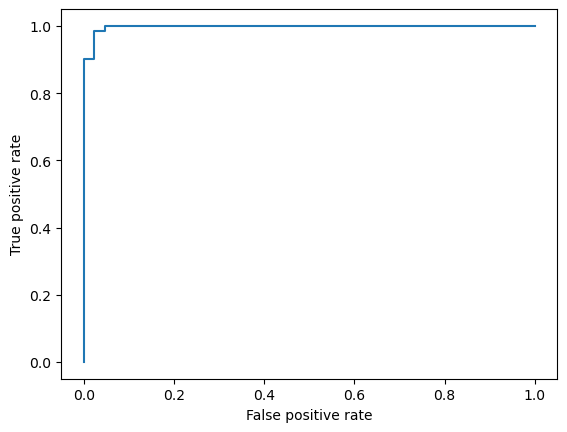

In [ ]:
plt.plot(fpr_log_reg, tpr_log_reg)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.show()

In [ ]:
pred_05 = (proba_log_reg[:, 1] >= 0.5).astype(int)
conf_mtx_05 = confusion_matrix(y_test, pred_05)
print(conf_mtx_05)

[[41  2]
 [ 1 70]]


In [ ]:
pred_09 = (proba_log_reg[:, 1] >= 0.9).astype(int)
conf_mtx_09 = confusion_matrix(y_test, pred_09)
print(conf_mtx_09)

[[42  1]
 [ 7 64]]


In [74]:
pred_opt = (proba_log_reg[0:, 1] >= 0.457300179).astype(int)
conf_mtx_opt = confusion_matrix(y_test, pred_opt)
print(conf_mtx_opt)

[[41  2]
 [ 1 70]]
